In [1]:
! pip install pandas matplotlib numpy tensorflow scikit-learn
! pip install nvidia-cudnn-cu12==9.3.0.75

DEPRECATION: Loading egg at /root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/paddleseg-0.0.0.dev0-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
DEPRECATION: Loading egg at /root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/paddleseg-0.0.0.dev0-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
import os
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Input,
    Add,
    LayerNormalization
)

from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from boxe_utils import *
from stance_utils import *

In [5]:
def collapse_to_3_classes(label_6):
    mapping = {
        'Jab': 'Straight',
        'Cross': 'Straight',
        'Lead Hook': 'Hook',
        'Rear Hook': 'Hook',
        'Lead Uppercut': 'Uppercut',
        'Rear Uppercut': 'Uppercut',
    }
    return mapping[label_6]

In [4]:
TRAIN_VIDEOS = ["V1", "V2", "V7", "V8", "V3", "V4"]
TEST_VIDEOS  = ["V5", "V9", "V10"]

def load_concat(vids):
    Xs = []
    ys = []

    for v in vids:
        sk, lb = load_video(v)
        Xs.append(sk.astype(np.float32))
        ys.append(lb)

    return np.concatenate(Xs), np.concatenate(ys)

X_tr_all, y_tr_all = load_concat(TRAIN_VIDEOS)
# X_cv, y_cv_raw = load_concat(CV_VIDEOS)
X_te, y_te_raw = load_concat(TEST_VIDEOS)

print(f"X_tr_all shape: {X_tr_all.shape}")
print(f"y_tr_all shape: {y_tr_all.shape}")
#print(f"X_cv shape: {X_cv.shape}")
#print(f"y_cv_raw shape: {y_cv_raw.shape}")
print(f"X_te shape: {X_te.shape}")
print(f"y_te_raw shape: {y_te_raw.shape}")

X_tr_all shape: (3867, 25, 17, 2)
y_tr_all shape: (3867,)
X_te shape: (899, 25, 17, 2)
y_te_raw shape: (899,)


In [6]:
y_tr_all = np.array([collapse_to_3_classes(y) for y in y_tr_all])
# y_cv_raw = np.array([collapse_to_3_classes(y) for y in y_cv_raw])
y_te_raw = np.array([collapse_to_3_classes(y) for y in y_te_raw])

classes, label_to_id, id_to_label = build_label_mapping(y_tr_all)

y_tr_all_id = np.array([label_to_id[x] for x in y_tr_all])
# y_cv = np.array([label_to_id[x] for x in y_cv_raw])
y_te = np.array([label_to_id[x] for x in y_te_raw])

num_classes = len(classes)

print(f"Classes: {classes}")
print(f"label_to_id: {label_to_id}")
print(f"num_classes: {num_classes}")
print(f"\ny_tr_all_id unique values: {np.unique(y_tr_all_id)}")
print(f"y_tr_all_id distribution:")
unique, counts = np.unique(y_tr_all_id, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {id_to_label[u]}: {c}")

Classes: ['Hook', 'Straight', 'Uppercut']
label_to_id: {'Hook': 0, 'Straight': 1, 'Uppercut': 2}
num_classes: 3

y_tr_all_id unique values: [0 1 2]
y_tr_all_id distribution:
  Hook: 1035
  Straight: 2139
  Uppercut: 693


In [7]:
tr_idx, val_idx = train_test_split(
    np.arange(len(y_tr_all_id)),
    test_size=0.35,
    stratify=y_tr_all_id,
    random_state=42
)

X_tr = X_tr_all[tr_idx]
y_tr = y_tr_all_id[tr_idx]

X_val = X_tr_all[val_idx]
y_val = y_tr_all_id[val_idx]

print(f"X_tr shape: {X_tr.shape}, y_tr shape: {y_tr.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"\nTrain distribution:")
unique, counts = np.unique(y_tr, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {id_to_label[u]}: {c}")
print(f"\nVal distribution:")
unique, counts = np.unique(y_val, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {id_to_label[u]}: {c}")

X_tr shape: (2513, 25, 17, 2), y_tr shape: (2513,)
X_val shape: (1354, 25, 17, 2), y_val shape: (1354,)

Train distribution:
  Hook: 673
  Straight: 1390
  Uppercut: 450

Val distribution:
  Hook: 362
  Straight: 749
  Uppercut: 243


In [8]:
def axis_stats(X):

    B = body_frame_windows(X)

    x = B[...,0]
    y = B[...,1]

    mean = np.array([
        x[x != 0].mean(),
        y[y != 0].mean()
    ])

    std = np.array([
        x[x != 0].std() + 1e-6,
        y[y != 0].std() + 1e-6
    ])

    return mean.astype(np.float32), std.astype(np.float32)

def std_va(B):

    X = B.reshape(len(B), WINDOW_LEN, 34).copy()

    X[:,:,0::2] = (X[:,:,0::2] - mean[0]) / std[0]
    X[:,:,1::2] = (X[:,:,1::2] - mean[1]) / std[1]

    return add_velocity_and_acceleration(X)

def feats(X):
    return std_va(body_frame_windows(X))

In [11]:
mean, std = axis_stats(X_tr)

np.savez(
    "norm_stats.npz",
    mean=mean,
    std=std
)

SWAP_J = [
    (1,2),
    (3,4),
    (5,6),
    (7,8),
    (9,10),
    (11,12),
    (13,14),
    (15,16)
]

def flip_body(B):

    F = B.copy()

    F[...,0] *= -1

    for a,b in SWAP_J:
        tmp = F[:,:,a,:].copy()
        F[:,:,a,:] = F[:,:,b,:]
        F[:,:,b,:] = tmp

    return F

# Processe os labels para treino e validação
#y_tr_all_id = np.array([label_to_id[collapse_to_3_classes(y)] for y in y_tr_all])
#y_val = np.array([label_to_id[collapse_to_3_classes(y)] for y in y_val_raw])
#y_te = np.array([label_to_id[collapse_to_3_classes(y)] for y in y_te_raw])

# Lembre-se de manter o espelhamento apenas no X_tr_all:
B_tr = body_frame_windows(X_tr_all) # Usando o treino completo
X_tr_feat = np.concatenate([std_va(B_tr), std_va(flip_body(B_tr))])
y_tr_final = np.concatenate([y_tr_all_id, y_tr_all_id])

print(f"X_tr_feat shape: {X_tr_feat.shape} (original + mirrored)")
print(f"y_tr_final shape: {y_tr_final.shape}")
print(f"\ny_tr_final distribution:")
unique, counts = np.unique(y_tr_final, return_counts=True)
for u, c in zip(unique, counts):
    pct = 100 * c / len(y_tr_final)
    print(f"  {id_to_label[u]}: {c} ({pct:.1f}%)")


X_tr_feat shape: (7734, 25, 102) (original + mirrored)
y_tr_final shape: (7734,)

y_tr_final distribution:
  Hook: 2070 (26.8%)
  Straight: 4278 (55.3%)
  Uppercut: 1386 (17.9%)


In [16]:
def build_model(input_shape, nc):

    inp = Input(shape=input_shape)

    x = Bidirectional(
        LSTM(
            64,
            return_sequences=True,
            dropout=0.3,
            recurrent_dropout=0.2
        )
    )(inp)

    x = Dropout(0.3)(x)

    att = MultiHeadAttention(
        num_heads=2,
        key_dim=32
    )(x,x)

    x = Add()([x,att])
    x = LayerNormalization()(x)

    x = GlobalAveragePooling1D()(x)

    x = Dense(
        64,
        activation="relu",
        kernel_regularizer=l2(5e-4)
    )(x)

    x = Dropout(0.3)(x)

    out = Dense(
        nc,
        activation="softmax"
    )(x)

    return Model(inp,out)

model = build_model(
    input_shape=X_tr_feat.shape[1:],
    nc=num_classes
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.0
    ),
    metrics=["accuracy"]
)

model.summary()

I0000 00:00:1782007024.976369   21992 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 56725 MB memory:  -> device: 0, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:1b:00.0, compute capability: 9.0a
I0000 00:00:1782007024.990219   21992 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 78666 MB memory:  -> device: 1, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:43:00.0, compute capability: 9.0a
I0000 00:00:1782007025.009424   21992 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 78754 MB memory:  -> device: 2, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:52:00.0, compute capability: 9.0a
I0000 00:00:1782007025.029011   21992 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 78756 MB memory:  -> device: 3, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:61:00.0, compute capability: 9.0a
I0000 00:00:1782007025.035736   21992 gpu_device.cc:2043] Cr

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 25, 102)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 25, 128)   │     85,504 │ input_layer[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 25, 128)   │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 25, 128)   │     33,088 │ dropout[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 25, 128)   │          0 │ dropout[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 25, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        195 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 127,299 (497.26 KB)

 Trainable params: 127,299 (497.26 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
weights = compute_class_weight(
    "balanced",
    classes=np.unique(y_tr_final),
    y=y_tr_final
)

class_weights = dict(enumerate(weights))

class_weights[label_to_id["Hook"]] *= 2.5
class_weights[label_to_id["Uppercut"]] *= 2.5

In [18]:
callbacks = [

    EarlyStopping(
        monitor="val_accuracy",
        patience=15,
        restore_best_weights=True,
        mode="max"
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        mode="min"
    ),

    ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    )
]

In [19]:
y_tr_oh = tf.keras.utils.to_categorical(
    y_tr_final,
    num_classes
)

y_val_oh = tf.keras.utils.to_categorical(
    y_val,
    num_classes
)

model.fit(
    X_tr_feat,
    y_tr_oh,
    validation_data=(feats(X_val), y_val_oh),
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.2944 - loss: 2.0293 - val_accuracy: 0.3951 - val_loss: 1.1726 - learning_rate: 5.0000e-04
Epoch 2/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - accuracy: 0.3814 - loss: 1.8663 - val_accuracy: 0.5192 - val_loss: 1.0690 - learning_rate: 5.0000e-04
Epoch 3/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.4761 - loss: 1.7551 - val_accuracy: 0.5842 - val_loss: 1.0035 - learning_rate: 5.0000e-04
Epoch 4/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - accuracy: 0.5415 - loss: 1.6732 - val_accuracy: 0.7009 - val_loss: 0.7649 - learning_rate: 5.0000e-04
Epoch 5/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.5778 - loss: 1.5935 - val_accuracy: 0.7312 - val_loss: 0.7350 - learning_rate: 5.0000e-04
Epoch 6/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.6144 - loss: 1.5036 - val_accuracy: 0.7179 - val_loss: 0.7406 - learning_rate: 5.0000e-04
Epoch 7/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 13s 5

29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step
              precision    recall  f1-score   support

        Hook       0.67      0.74      0.70       172
    Straight       0.92      0.85      0.89       519
    Uppercut       0.75      0.82      0.78       208

    accuracy                           0.82       899
   macro avg       0.78      0.81      0.79       899
weighted avg       0.83      0.82      0.83       899



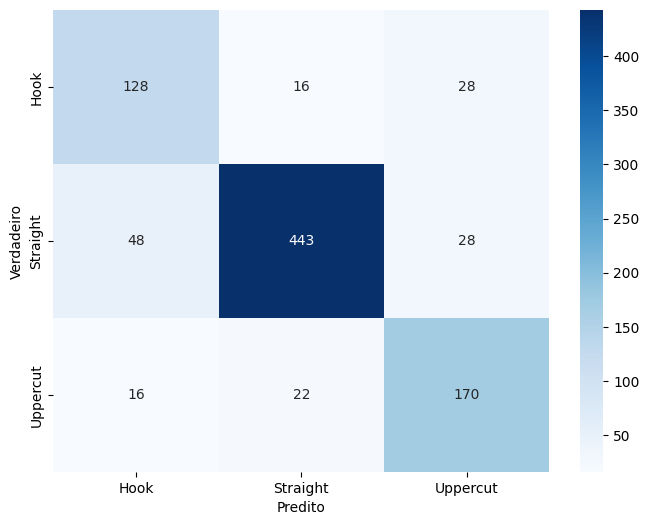

In [12]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Carregar o melhor modelo salvo
best_model = load_model("best_model.keras")

# 2. EXTRAIR AS CORREÇÕES/FEATURES DO CONJUNTO DE TESTE (Adicione esta linha!)
X_te_feat = feats(X_te) 

# 3. Fazer a predição
y_pred = np.argmax(best_model.predict(X_te_feat), axis=1)

# 4. Relatório de classificação (garanta que classes_3 ou classes esteja definido)
print(classification_report(y_te, y_pred, target_names=classes))

# 5. Matriz de Confusão
cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes,
            cmap='Blues')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.savefig("matrix.png")
plt.show()

In [13]:
best_model.save("modelo_boxe.keras")